# 05 — Extended Next-Day Daily Total Forecasting 20 Years 

**Mục tiêu:** mở rộng bài toán `next-day daily total forecasting` từ dữ liệu 3 năm lên dữ liệu **20 năm (2004–2023)** để kiểm tra xem việc tăng kích thước dữ liệu có cải thiện kết quả daily forecasting hay không.

Notebook này đọc 4 file NASA POWER Hourly bạn đã tải thủ công và đặt trong thư mục `data_05/`:

- `nasa_power_errachidia_hourly_2004_2008_LST.csv`
- `nasa_power_errachidia_hourly_2009_2013_LST.csv`
- `nasa_power_errachidia_hourly_2014_2018_LST.csv`
- `nasa_power_errachidia_hourly_2019_2023_LST.csv`

Pipeline chính:

1. Đọc và nối 4 file NASA POWER Hourly.
2. Làm sạch dữ liệu hourly và tạo `Solar_Energy_kJ_m2`.
3. Gom hourly thành daily total.
4. Tạo bài toán `next-day daily total forecasting`.
5. Tạo lag/rolling/calendar/weather/physical features ở cấp ngày.
6. Train baseline + ML models: Ridge, RandomForest, HGBR, XGBoost, CatBoost, SVR, MLP.
7. Tuning nhẹ HGBR.
8. Ablation study.
9. Chọn best model theo validation RMSE.
10. Phân tích lỗi, feature importance và so sánh với notebook 04 nếu có.

Output lưu gọn trong:

- `data_05/` — raw/manual NASA POWER CSV và file combined.
- `outputs_05/` — bảng kết quả chính.
- `figures_05/` — hình minh họa.
- `models_05/` — best model.

In [1]:
# =========================
# 0. Configuration
# =========================

from pathlib import Path
import sys
import time
import json
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, max_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
import joblib

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

SEED = 42
np.random.seed(SEED)

# Errachidia, Morocco
LATITUDE = 31.93
LONGITUDE = -4.42
TIME_STANDARD = "LST"


RUN_EXPENSIVE_MODELS = True
RUN_HGBR_TUNING = True
RUN_ABLATION = True
RUN_PERMUTATION_IMPORTANCE = True

DATA_DIR = Path("data_05")
OUT_DIR = Path("outputs_05")
FIG_DIR = Path("figures_05")
MODEL_DIR = Path("models_05")
for p in [DATA_DIR, OUT_DIR, FIG_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

MANUAL_FILES = [
    DATA_DIR / "nasa_power_errachidia_hourly_2004_2008_LST.csv",
    DATA_DIR / "nasa_power_errachidia_hourly_2009_2013_LST.csv",
    DATA_DIR / "nasa_power_errachidia_hourly_2014_2018_LST.csv",
    DATA_DIR / "nasa_power_errachidia_hourly_2019_2023_LST.csv",
]

COMBINED_CSV_PATH = DATA_DIR / "nasa_power_errachidia_hourly_2004_2023_LST_combined.csv"

print("Python executable:", sys.executable)
print("Output folders ready.")
print("Manual files expected:")
for p in MANUAL_FILES:
    print(" -", p)

Python executable: c:\Users\nguye\AppData\Local\Programs\Python\Python314\python.exe
Output folders ready.
Manual files expected:
 - data_05\nasa_power_errachidia_hourly_2004_2008_LST.csv
 - data_05\nasa_power_errachidia_hourly_2009_2013_LST.csv
 - data_05\nasa_power_errachidia_hourly_2014_2018_LST.csv
 - data_05\nasa_power_errachidia_hourly_2019_2023_LST.csv


## 1. Load manually downloaded NASA POWER files

Cell này chỉ đọc 4 file data

In [2]:
# =========================
# 1. Load manually downloaded NASA POWER Hourly CSV files
# =========================

def read_power_hourly_csv(path):
    """Read NASA POWER CSV by locating the actual header line that starts with YEAR."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    lines = path.read_text(encoding="utf-8", errors="ignore").splitlines()
    header_idx = None
    for i, line in enumerate(lines):
        stripped = line.strip()
        if stripped.startswith("YEAR,MO,DY,HR") or stripped.startswith("YEAR,MO,DY,HR,"):
            header_idx = i
            break
        if stripped.startswith("YEAR") and "MO" in stripped and "DY" in stripped and "HR" in stripped:
            header_idx = i
            break

    if header_idx is None:
        raise ValueError(f"Could not find NASA POWER data header in file: {path}")

    df_part = pd.read_csv(path, skiprows=header_idx)
    df_part.columns = [str(c).strip() for c in df_part.columns]
    return df_part

missing_files = [str(p) for p in MANUAL_FILES if not p.exists()]
if missing_files:
    raise FileNotFoundError("Missing NASA POWER files:\n" + "\n".join(missing_files))

raw_parts = []
for path in MANUAL_FILES:
    part = read_power_hourly_csv(path)
    raw_parts.append(part)
    print(f"{path.name}: {part.shape}")

raw_df = pd.concat(raw_parts, ignore_index=True)

required_time_cols = ["YEAR", "MO", "DY", "HR"]
missing_time_cols = [c for c in required_time_cols if c not in raw_df.columns]
if missing_time_cols:
    raise ValueError(f"Missing required time columns: {missing_time_cols}")

# Remove duplicated timestamps if any and sort chronologically
raw_df = raw_df.drop_duplicates(subset=required_time_cols).copy()
raw_df = raw_df.sort_values(required_time_cols).reset_index(drop=True)

print("Combined raw shape:", raw_df.shape)
display(raw_df.head())
display(raw_df.tail())

# Save combined file for reproducibility and faster re-use
raw_df.to_csv(COMBINED_CSV_PATH, index=False)
print("Saved combined CSV to:", COMBINED_CSV_PATH)

nasa_power_errachidia_hourly_2004_2008_LST.csv: (43848, 10)
nasa_power_errachidia_hourly_2009_2013_LST.csv: (43824, 10)
nasa_power_errachidia_hourly_2014_2018_LST.csv: (43824, 10)
nasa_power_errachidia_hourly_2019_2023_LST.csv: (43824, 10)
Combined raw shape: (175320, 10)


,YEAR,MO,DY,HR,PS,WS10M,WD10M,RH2M,ALLSKY_SFC_SW_DWN,T2M
0,2004,1,1,0,87.48,3.75,331.3,90.18,0.0,3.69
1,2004,1,1,1,87.49,4.01,336.3,93.09,0.0,3.38
2,2004,1,1,2,87.48,4.20,340.8,94.70,0.0,3.19
3,2004,1,1,3,87.45,4.40,342.8,95.65,0.0,2.99
4,2004,1,1,4,87.42,4.31,342.0,96.39,0.0,2.74


,YEAR,MO,DY,HR,PS,WS10M,WD10M,RH2M,ALLSKY_SFC_SW_DWN,T2M
175315,2023,12,31,19,87.44,3.05,189.8,30.12,0.0,7.60
175316,2023,12,31,20,87.48,2.89,205.6,32.86,0.0,6.53
175317,2023,12,31,21,87.49,2.75,218.7,34.88,0.0,5.86
175318,2023,12,31,22,87.49,2.53,227.7,35.23,0.0,5.90
175319,2023,12,31,23,87.46,2.32,232.5,35.37,0.0,5.84


Saved combined CSV to: data_05\nasa_power_errachidia_hourly_2004_2023_LST_combined.csv


## 2. Clean hourly data

NASA POWER hourly data được đổi tên cột về dạng dễ hiểu hơn. `ALLSKY_SFC_SW_DWN` được xem là bức xạ theo giờ và chuyển sang `Solar_Energy_kJ_m2` bằng quy đổi `1 Wh = 3.6 kJ`.

In [3]:
# =========================
# 2. Clean hourly data
# =========================

raw_df = raw_df.replace(-999, np.nan)

# Convert all columns to numeric when possible
for c in raw_df.columns:
    raw_df[c] = pd.to_numeric(raw_df[c], errors="coerce")

# Create datetime index
hourly = raw_df.copy()
hourly[required_time_cols] = hourly[required_time_cols].astype(int)
hourly["datetime"] = pd.to_datetime(
    dict(
        year=hourly["YEAR"],
        month=hourly["MO"],
        day=hourly["DY"],
        hour=hourly["HR"],
    ),
    errors="coerce",
)
hourly = hourly.dropna(subset=["datetime"]).set_index("datetime").sort_index()

rename_map = {
    "PS": "Pressure_kPa",
    "WS10M": "Wind_Speed_m_s",
    "WD10M": "Wind_Direction_deg",
    "RH2M": "Humidity_pct",
    "ALLSKY_SFC_SW_DWN": "Solar_Radiation_Wh_m2",
    "T2M": "Temperature_C",
}
hourly = hourly.rename(columns=rename_map)

required_vars = [
    "Solar_Radiation_Wh_m2",
    "Temperature_C",
    "Humidity_pct",
    "Pressure_kPa",
    "Wind_Speed_m_s",
    "Wind_Direction_deg",
]
missing_vars = [c for c in required_vars if c not in hourly.columns]
if missing_vars:
    raise ValueError(f"Missing required NASA variables after renaming: {missing_vars}")

hourly["Solar_Energy_kJ_m2"] = hourly["Solar_Radiation_Wh_m2"] * 3.6

# Keep only needed columns plus original time columns for inspection
hourly = hourly.loc[:, ~hourly.columns.duplicated()].copy()

print("Clean hourly shape:", hourly.shape)
print("Date range:", hourly.index.min(), "→", hourly.index.max())
print("Expected approximate hourly rows for 20 years:", 20 * 365 * 24 + 5 * 24)  # leap years 2004, 2008, 2012, 2016, 2020
print("Missing values in core variables:")
display(hourly[["Solar_Radiation_Wh_m2", "Solar_Energy_kJ_m2", "Temperature_C", "Humidity_pct", "Pressure_kPa", "Wind_Speed_m_s"]].isna().sum())
display(hourly.head())

Clean hourly shape: (175320, 11)
Date range: 2004-01-01 00:00:00 → 2023-12-31 23:00:00
Expected approximate hourly rows for 20 years: 175320
Missing values in core variables:


Solar_Radiation_Wh_m2    0
Solar_Energy_kJ_m2       0
Temperature_C            0
Humidity_pct             0
Pressure_kPa             0
Wind_Speed_m_s           0
dtype: int64

,YEAR,MO,DY,HR,Pressure_kPa,Wind_Speed_m_s,Wind_Direction_deg,Humidity_pct,Solar_Radiation_Wh_m2,Temperature_C,Solar_Energy_kJ_m2
datetime,,,,,,,,,,,
2004-01-01 00:00:00,2004,1,1,0,87.48,3.75,331.3,90.18,0.0,3.69,0.0
2004-01-01 01:00:00,2004,1,1,1,87.49,4.01,336.3,93.09,0.0,3.38,0.0
2004-01-01 02:00:00,2004,1,1,2,87.48,4.20,340.8,94.70,0.0,3.19,0.0
2004-01-01 03:00:00,2004,1,1,3,87.45,4.40,342.8,95.65,0.0,2.99,0.0
2004-01-01 04:00:00,2004,1,1,4,87.42,4.31,342.0,96.39,0.0,2.74,0.0


## 3. Quick EDA on the 20-year hourly data

Các biểu đồ này dùng để kiểm tra dữ liệu đã nối đúng và thể hiện chu kỳ ngày/mùa của năng lượng mặt trời.

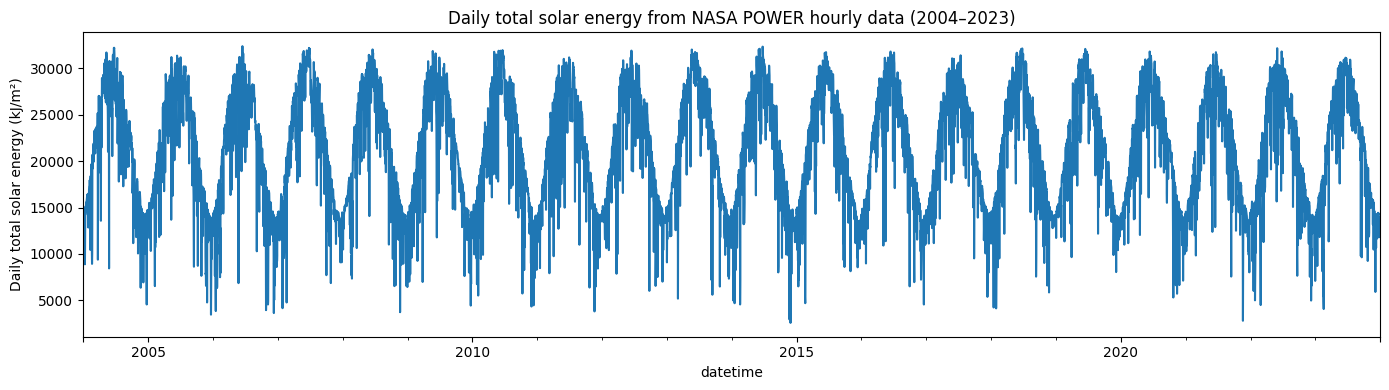

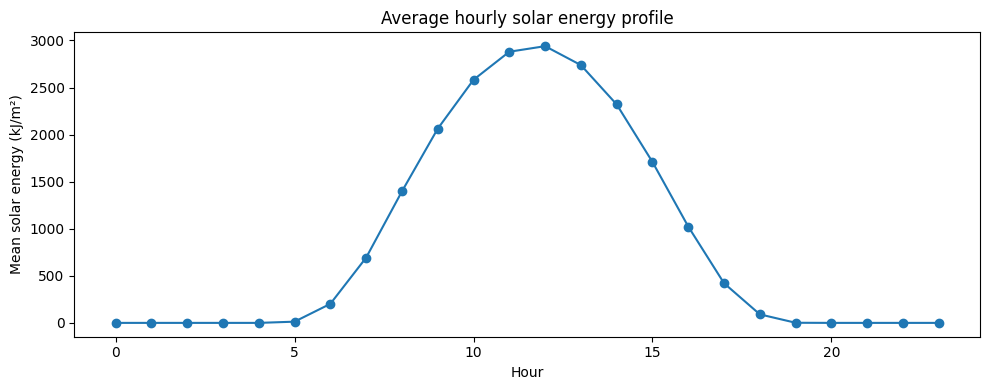

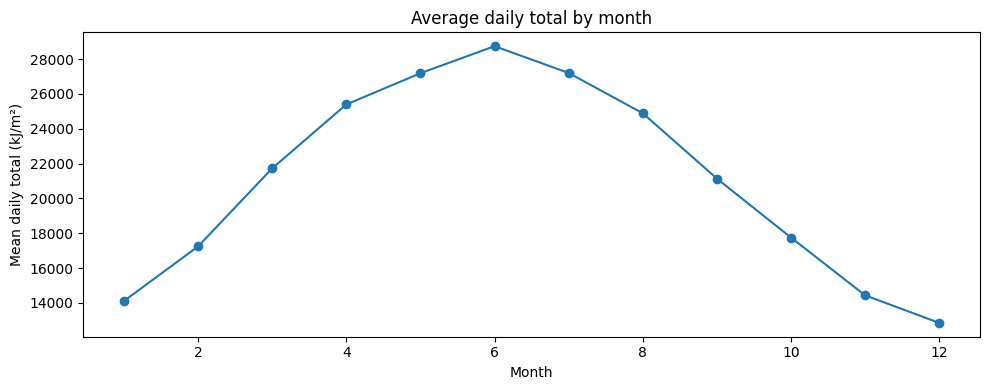

In [4]:
# =========================
# 3. Quick EDA
# =========================

plt.figure(figsize=(14, 4))
hourly["Solar_Energy_kJ_m2"].resample("D").sum().plot()
plt.title("Daily total solar energy from NASA POWER hourly data (2004–2023)")
plt.ylabel("Daily total solar energy (kJ/m²)")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_daily_total_timeseries_2004_2023.png", dpi=160)
plt.show()

plt.figure(figsize=(10, 4))
hourly.groupby(hourly.index.hour)["Solar_Energy_kJ_m2"].mean().plot(marker="o")
plt.title("Average hourly solar energy profile")
plt.xlabel("Hour")
plt.ylabel("Mean solar energy (kJ/m²)")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_avg_hourly_profile.png", dpi=160)
plt.show()

plt.figure(figsize=(10, 4))
hourly["Solar_Energy_kJ_m2"].resample("D").sum().groupby(lambda x: x.month).mean().plot(marker="o")
plt.title("Average daily total by month")
plt.xlabel("Month")
plt.ylabel("Mean daily total (kJ/m²)")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_avg_daily_total_by_month.png", dpi=160)
plt.show()

## 4. Hourly → daily aggregation

Mỗi dòng daily là một ngày. Target chính là `target_next_day_total_kJ_m2`, tức tổng năng lượng mặt trời của ngày kế tiếp.

In [5]:
# =========================
# 4. Hourly -> daily aggregation
# =========================

# Daily aggregation
daily = pd.DataFrame(index=hourly.resample("D").sum().index)
daily["daily_total_kJ_m2"] = hourly["Solar_Energy_kJ_m2"].resample("D").sum()
daily["daily_radiation_Wh_m2"] = hourly["Solar_Radiation_Wh_m2"].resample("D").sum()
daily["temp_mean_C"] = hourly["Temperature_C"].resample("D").mean()
daily["temp_max_C"] = hourly["Temperature_C"].resample("D").max()
daily["temp_min_C"] = hourly["Temperature_C"].resample("D").min()
daily["humidity_mean_pct"] = hourly["Humidity_pct"].resample("D").mean()
daily["pressure_mean_kPa"] = hourly["Pressure_kPa"].resample("D").mean()
daily["wind_speed_mean_m_s"] = hourly["Wind_Speed_m_s"].resample("D").mean()

# Circular mean for wind direction
wd_rad = np.deg2rad(hourly["Wind_Direction_deg"])
wd_sin_daily = pd.Series(np.sin(wd_rad), index=hourly.index).resample("D").mean()
wd_cos_daily = pd.Series(np.cos(wd_rad), index=hourly.index).resample("D").mean()
daily["wind_dir_sin_mean"] = wd_sin_daily
daily["wind_dir_cos_mean"] = wd_cos_daily

# Calendar known at current day D and target day D+1
daily["date"] = daily.index
daily["year"] = daily.index.year
daily["month"] = daily.index.month
daily["dayofyear"] = daily.index.dayofyear
daily["target_date"] = daily.index + pd.Timedelta(days=1)
daily["target_month"] = daily["target_date"].dt.month
daily["target_dayofyear"] = daily["target_date"].dt.dayofyear

# Target-day cyclic features, known in advance
daily["target_doy_sin"] = np.sin(2 * np.pi * daily["target_dayofyear"] / 365.25)
daily["target_doy_cos"] = np.cos(2 * np.pi * daily["target_dayofyear"] / 365.25)
daily["target_month_sin"] = np.sin(2 * np.pi * daily["target_month"] / 12)
daily["target_month_cos"] = np.cos(2 * np.pi * daily["target_month"] / 12)

# Target: next-day daily total
daily["target_next_day_total_kJ_m2"] = daily["daily_total_kJ_m2"].shift(-1)

print("Daily raw shape:", daily.shape)
print("Daily range:", daily.index.min(), "→", daily.index.max())
display(daily.head())
display(daily.tail())

Daily raw shape: (7305, 22)
Daily range: 2004-01-01 00:00:00 → 2023-12-31 00:00:00


,daily_total_kJ_m2,daily_radiation_Wh_m2,temp_mean_C,temp_max_C,temp_min_C,humidity_mean_pct,pressure_mean_kPa,wind_speed_mean_m_s,wind_dir_sin_mean,wind_dir_cos_mean,...,month,dayofyear,target_date,target_month,target_dayofyear,target_doy_sin,target_doy_cos,target_month_sin,target_month_cos,target_next_day_total_kJ_m2
datetime,,,,,,,,,,,,,,,,,,,,,
2004-01-01,13583.484,3773.19,8.701667,16.94,2.46,64.045833,87.393750,2.826667,-0.577400,0.046274,...,1,1,2004-01-02,1,2,0.034398,0.999408,0.5,0.866025,13932.648
2004-01-02,13932.648,3870.18,9.576250,18.79,2.69,59.697917,87.030000,1.756250,-0.448858,0.767043,...,1,2,2004-01-03,1,3,0.051584,0.998669,0.5,0.866025,14158.836
2004-01-03,14158.836,3933.01,7.555417,15.96,2.39,69.373333,86.823333,5.590000,-0.035559,0.968671,...,1,3,2004-01-04,1,4,0.068755,0.997634,0.5,0.866025,14227.884
2004-01-04,14227.884,3952.19,7.118333,14.74,1.93,65.430417,87.022500,1.687083,-0.145478,0.124219,...,1,4,2004-01-05,1,5,0.085906,0.996303,0.5,0.866025,14320.368
2004-01-05,14320.368,3977.88,6.542917,14.03,2.44,57.253750,87.384583,2.417917,-0.020108,-0.257125,...,1,5,2004-01-06,1,6,0.103031,0.994678,0.5,0.866025,13817.952


,daily_total_kJ_m2,daily_radiation_Wh_m2,temp_mean_C,temp_max_C,temp_min_C,humidity_mean_pct,pressure_mean_kPa,wind_speed_mean_m_s,wind_dir_sin_mean,wind_dir_cos_mean,...,month,dayofyear,target_date,target_month,target_dayofyear,target_doy_sin,target_doy_cos,target_month_sin,target_month_cos,target_next_day_total_kJ_m2
datetime,,,,,,,,,,,,,,,,,,,,,
2023-12-27,13809.996,3836.11,7.252083,15.57,0.30,30.423750,87.466667,1.878750,0.207221,0.847059,...,12,361,2023-12-28,12,362,-0.055879,0.998438,-2.449294e-16,1.000000,13776.120
2023-12-28,13776.120,3826.70,8.541250,18.08,2.32,26.811250,87.770417,2.175417,-0.079262,-0.062163,...,12,362,2023-12-29,12,363,-0.038696,0.999251,-2.449294e-16,1.000000,13465.440
2023-12-29,13465.440,3740.40,9.817083,17.73,5.06,25.411667,87.772500,2.618750,-0.615790,-0.562596,...,12,363,2023-12-30,12,364,-0.021501,0.999769,-2.449294e-16,1.000000,13616.316
2023-12-30,13616.316,3782.31,10.267917,18.18,5.49,22.999583,87.501667,2.169583,-0.556808,0.072961,...,12,364,2023-12-31,12,365,-0.004301,0.999991,-2.449294e-16,1.000000,13526.820
2023-12-31,13526.820,3757.45,9.490000,17.17,5.46,26.495000,87.477500,2.627083,-0.086039,-0.191117,...,12,365,2024-01-01,1,1,0.017202,0.999852,5.000000e-01,0.866025,NaN


## 5. Daily feature engineering

Quan trọng: toàn bộ lag/rolling đều dùng dữ liệu đã biết đến ngày D để dự báo tổng năng lượng của ngày D+1. Không dùng thời tiết thật của ngày D+1, trừ các đặc trưng lịch/clear-sky proxy có thể biết trước từ ngày trong năm và tọa độ.

In [6]:
# =========================
# 5. Feature engineering for next-day daily total forecasting
# =========================

feat = daily.copy()

# Daily total lag features. Include lag_6 and lag_364 for target-day seasonal baselines.
lag_days = [1, 2, 3, 6, 7, 14, 21, 30, 60, 90, 180, 364, 365]
for lag in lag_days:
    feat[f"daily_total_lag_{lag}d"] = feat["daily_total_kJ_m2"].shift(lag)

# Rolling features from known past only
shifted_total = feat["daily_total_kJ_m2"].shift(1)
for w in [3, 7, 14, 30, 60, 90, 180, 365]:
    min_p = max(2, min(w, 7))
    feat[f"daily_total_roll_mean_{w}d"] = shifted_total.rolling(w, min_periods=min_p).mean()
    feat[f"daily_total_roll_std_{w}d"] = shifted_total.rolling(w, min_periods=min_p).std()
    feat[f"daily_total_roll_min_{w}d"] = shifted_total.rolling(w, min_periods=min_p).min()
    feat[f"daily_total_roll_max_{w}d"] = shifted_total.rolling(w, min_periods=min_p).max()

# Weather lag and rolling features from known past/current day only
weather_daily_cols = [
    "temp_mean_C", "temp_max_C", "temp_min_C",
    "humidity_mean_pct", "pressure_mean_kPa", "wind_speed_mean_m_s",
    "wind_dir_sin_mean", "wind_dir_cos_mean",
]

for col in weather_daily_cols:
    if col in feat.columns:
        for lag in [1, 2, 7, 30]:
            feat[f"{col}_lag_{lag}d"] = feat[col].shift(lag)
        shifted_col = feat[col].shift(1)
        for w in [7, 30, 90]:
            feat[f"{col}_roll_mean_{w}d"] = shifted_col.rolling(w, min_periods=max(2, min(w, 7))).mean()

# Simple daily clear-sky / physical proxy for target day, known from calendar and latitude
lat_rad = np.deg2rad(LATITUDE)
target_doy = feat["target_dayofyear"].astype(float)
current_doy = feat["dayofyear"].astype(float)

def noon_solar_elevation_from_doy(doy):
    decl = np.deg2rad(23.44) * np.sin(2 * np.pi * (doy - 81) / 365.25)
    elev = np.arcsin(np.sin(lat_rad) * np.sin(decl) + np.cos(lat_rad) * np.cos(decl))
    return np.rad2deg(elev)

feat["target_noon_solar_elevation_deg"] = noon_solar_elevation_from_doy(target_doy)
feat["current_noon_solar_elevation_deg"] = noon_solar_elevation_from_doy(current_doy)

# Clear-sky proxies: not physically exact, but deterministic and useful as seasonality/clear-sky context
feat["target_clear_sky_daily_proxy"] = np.clip(np.sin(np.deg2rad(feat["target_noon_solar_elevation_deg"])), 0, None) * 24 * 1000 * 3.6
feat["current_clear_sky_daily_proxy"] = np.clip(np.sin(np.deg2rad(feat["current_noon_solar_elevation_deg"])), 0, None) * 24 * 1000 * 3.6

feat["current_clear_sky_index_daily"] = feat["daily_total_kJ_m2"] / feat["current_clear_sky_daily_proxy"].replace(0, np.nan)
feat["current_clear_sky_index_daily"] = feat["current_clear_sky_index_daily"].clip(lower=0, upper=2)

# Simple simulated PV daily proxy from current day data only
feat["sim_cell_temperature_daily_C"] = feat["temp_mean_C"] + 0.03 * (feat["daily_radiation_Wh_m2"] / 24)
temp_coeff = -0.004
feat["sim_pv_daily_kWh_per_kWp"] = (feat["daily_radiation_Wh_m2"] / 1000.0) * (1 + temp_coeff * (feat["sim_cell_temperature_daily_C"] - 25))
feat["sim_pv_daily_kWh_per_kWp"] = feat["sim_pv_daily_kWh_per_kWp"].clip(lower=0)
for lag in [1, 2, 7, 30]:
    feat[f"sim_pv_daily_lag_{lag}d"] = feat["sim_pv_daily_kWh_per_kWp"].shift(lag)

feature_target_col = "target_next_day_total_kJ_m2"

# Replace infinities and drop rows missing target/features caused by lag/rolling
feat = feat.replace([np.inf, -np.inf], np.nan)
feat_model = feat.dropna().copy()
feat_model = feat_model.loc[:, ~feat_model.columns.duplicated()].copy()

print("Feature dataframe shape:", feat_model.shape)
print("Feature range:", feat_model.index.min(), "→", feat_model.index.max())
display(feat_model.head())

Feature dataframe shape: (6939, 134)
Feature range: 2004-12-31 00:00:00 → 2023-12-30 00:00:00


,daily_total_kJ_m2,daily_radiation_Wh_m2,temp_mean_C,temp_max_C,temp_min_C,humidity_mean_pct,pressure_mean_kPa,wind_speed_mean_m_s,wind_dir_sin_mean,wind_dir_cos_mean,...,current_noon_solar_elevation_deg,target_clear_sky_daily_proxy,current_clear_sky_daily_proxy,current_clear_sky_index_daily,sim_cell_temperature_daily_C,sim_pv_daily_kWh_per_kWp,sim_pv_daily_lag_1d,sim_pv_daily_lag_2d,sim_pv_daily_lag_7d,sim_pv_daily_lag_30d
datetime,,,,,,,,,,,,,,,,,,,,,
2004-12-31,14346.252,3985.07,3.460417,11.40,-2.92,61.990833,87.844583,1.987500,-0.204079,0.247228,...,35.053158,49646.444505,49622.646128,0.289107,8.441754,4.249013,4.198757,4.063418,1.371115,4.163924
2005-01-01,14640.408,4066.78,4.764583,14.46,-1.31,52.228333,88.127083,3.258333,0.115520,0.960066,...,35.072439,49746.821540,49646.444505,0.294893,9.848058,4.313258,4.249013,4.198757,3.812718,4.117553
2005-01-02,14619.240,4060.90,6.342500,15.74,-0.45,47.735833,88.270000,3.042500,0.208572,0.848712,...,35.153812,49855.450315,49746.821540,0.293873,11.418625,4.281510,4.313258,4.249013,4.226221,4.201075
2005-01-03,14495.796,4026.61,6.633333,15.29,0.51,47.236667,88.127083,2.786250,0.421177,0.623926,...,35.241966,49972.271275,49855.450315,0.290756,11.666596,4.241364,4.281510,4.313258,3.763300,3.771053
2005-01-04,14294.376,3970.66,4.572917,11.90,0.32,57.485417,88.287083,2.420833,0.572182,0.035302,...,35.336875,50097.220346,49972.271275,0.286046,9.536242,4.216265,4.241364,4.281510,4.406464,2.051245


## 6. Train / Validation / Test split

Với dữ liệu 20 năm, split theo thời gian:

- Train: 2004–2018
- Validation: 2019–2020
- Test: 2021–2023

In [7]:
# =========================
# 6. Train / Validation / Test split
# =========================

train_df = feat_model.loc[:"2018-12-31"].copy()
val_df = feat_model.loc["2019-01-01":"2020-12-31"].copy()
test_df = feat_model.loc["2021-01-01":"2023-12-31"].copy()

exclude_cols = [
    feature_target_col,
    "date", "target_date",
    "year", "month", "dayofyear", "target_month", "target_dayofyear",
]
feature_cols = [
    c for c in feat_model.columns
    if c not in exclude_cols
    and pd.api.types.is_numeric_dtype(feat_model[c])
    and feat_model[c].nunique(dropna=True) > 1
]
feature_cols = list(dict.fromkeys(feature_cols))

print("Train:", train_df.shape, train_df.index.min(), "→", train_df.index.max())
print("Val  :", val_df.shape, val_df.index.min(), "→", val_df.index.max())
print("Test :", test_df.shape, test_df.index.min(), "→", test_df.index.max())
print("Number of feature columns:", len(feature_cols))

# Save dataset and feature columns
feat_model.to_csv(OUT_DIR / "05_daily_20y_feature_dataset.csv")
pd.Series(feature_cols, name="feature").to_csv(OUT_DIR / "05_daily_20y_feature_columns.csv", index=False)
print("Saved daily feature dataset and feature columns to:", OUT_DIR)

Train: (5114, 134) 2004-12-31 00:00:00 → 2018-12-31 00:00:00
Val  : (731, 134) 2019-01-01 00:00:00 → 2020-12-31 00:00:00
Test : (1094, 134) 2021-01-01 00:00:00 → 2023-12-30 00:00:00
Number of feature columns: 126
Saved daily feature dataset and feature columns to: outputs_05


## 7. Metrics, helper functions and baselines

Baselines:

- `Persistence`: dùng tổng năng lượng ngày D để dự báo ngày D+1.
- `SeasonalPersistence7d`: dùng tổng năng lượng của ngày tương ứng tuần trước của target day.
- `SeasonalPersistence365d`: dùng tổng năng lượng gần cùng ngày năm trước của target day.

In [8]:
# =========================
# 7. Metrics and helper functions
# =========================

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def nrmse(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    rng = np.max(y_true) - np.min(y_true)
    return float(rmse(y_true, y_pred) / rng) if rng != 0 else np.nan


def evaluate_predictions(y_true, y_pred, persistence_pred=None, seasonal7_pred=None, seasonal365_pred=None):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    n = min(len(y_true), len(y_pred))
    y_true = y_true[-n:]
    y_pred = y_pred[-n:]

    out = {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
        "MaxError": float(max_error(y_true, y_pred)),
        "NRMSE": nrmse(y_true, y_pred),
    }

    def skill_against(baseline):
        if baseline is None:
            return np.nan
        b = np.asarray(baseline).reshape(-1)
        m = min(len(y_true), len(b))
        yt = y_true[-m:]
        b = b[-m:]
        base_rmse = rmse(yt, b)
        model_rmse = rmse(y_true, y_pred)
        return float(1 - model_rmse / base_rmse) if base_rmse > 0 else np.nan

    out["skill_vs_persistence"] = skill_against(persistence_pred)
    out["skill_vs_seasonal7"] = skill_against(seasonal7_pred)
    out["skill_vs_seasonal365"] = skill_against(seasonal365_pred)
    return out


def print_metric_short(prefix, metrics):
    print(
        f"{prefix} | RMSE={metrics['RMSE']:.2f} | MAE={metrics['MAE']:.2f} | "
        f"R2={metrics['R2']:.4f} | Skill(P)={metrics['skill_vs_persistence']:.4f}"
    )


def make_clean_X(dataframe, cols):
    cols = list(dict.fromkeys([c for c in cols if c in dataframe.columns]))
    X = dataframe.loc[:, cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()
    X = X.apply(pd.to_numeric, errors="coerce")
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
    return X.astype(np.float32)


def make_X_y(dataframe, cols, target_col):
    X = make_clean_X(dataframe, cols)
    y = pd.to_numeric(dataframe[target_col], errors="coerce").astype(np.float32).values
    return X, y

X_train, y_train = make_X_y(train_df, feature_cols, feature_target_col)
X_val, y_val = make_X_y(val_df, feature_cols, feature_target_col)
X_test, y_test = make_X_y(test_df, feature_cols, feature_target_col)

p_val = val_df["daily_total_kJ_m2"].values.astype(np.float32)
p_test = test_df["daily_total_kJ_m2"].values.astype(np.float32)
s7_val = val_df["daily_total_lag_6d"].values.astype(np.float32)
s7_test = test_df["daily_total_lag_6d"].values.astype(np.float32)
s365_val = val_df["daily_total_lag_364d"].values.astype(np.float32)
s365_test = test_df["daily_total_lag_364d"].values.astype(np.float32)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

X_train: (5114, 126)
X_val  : (731, 126)
X_test : (1094, 126)


In [9]:
# =========================
# 8. Baseline models
# =========================

results = []
predictions = {}

baselines = {
    "Persistence": {"val_pred": p_val, "test_pred": p_test},
    "SeasonalPersistence7d": {"val_pred": s7_val, "test_pred": s7_test},
    "SeasonalPersistence365d": {"val_pred": s365_val, "test_pred": s365_test},
}

for model_name, preds in baselines.items():
    val_metrics = evaluate_predictions(y_val, preds["val_pred"], p_val, s7_val, s365_val)
    test_metrics = evaluate_predictions(y_test, preds["test_pred"], p_test, s7_test, s365_test)
    row = {
        "model": model_name,
        "model_type": "baseline",
        "n_features": 0,
        "train_seconds": 0.0,
        **{f"val_{k}": v for k, v in val_metrics.items()},
        **{f"test_{k}": v for k, v in test_metrics.items()},
    }
    results.append(row)
    predictions[model_name] = {
        "val_pred": preds["val_pred"],
        "test_pred": preds["test_pred"],
        "model": None,
    }
    print_metric_short(model_name + " Val ", val_metrics)
    print_metric_short(model_name + " Test", test_metrics)

Persistence Val  | RMSE=2836.73 | MAE=1847.72 | R2=0.7672 | Skill(P)=0.0000
Persistence Test | RMSE=3261.29 | MAE=2061.25 | R2=0.7166 | Skill(P)=0.0000
SeasonalPersistence7d Val  | RMSE=3836.59 | MAE=2699.83 | R2=0.5742 | Skill(P)=-0.3525
SeasonalPersistence7d Test | RMSE=4099.45 | MAE=2868.27 | R2=0.5521 | Skill(P)=-0.2570
SeasonalPersistence365d Val  | RMSE=3833.59 | MAE=2641.27 | R2=0.5748 | Skill(P)=-0.3514
SeasonalPersistence365d Test | RMSE=4275.21 | MAE=2966.33 | R2=0.5129 | Skill(P)=-0.3109


## 8. Train main machine learning models

Các mô hình chính gồm Linear/Ridge, Random Forest, HGBR, XGBoost, CatBoost. Nếu `RUN_EXPENSIVE_MODELS=True`, notebook chạy thêm SVR và MLP.

In [10]:
# =========================
# 9. Main ML models
# =========================

main_models = {
    "LinearRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0, random_state=SEED)),
    ]),
    "RandomForest": RandomForestRegressor(
        n_estimators=500,
        max_depth=14,
        min_samples_leaf=2,
        random_state=SEED,
        n_jobs=-1,
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=700,
        learning_rate=0.04,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=SEED,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=900,
        learning_rate=0.035,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1,
        tree_method="hist",
    ),
    "CatBoost": CatBoostRegressor(
        iterations=900,
        learning_rate=0.035,
        depth=6,
        loss_function="RMSE",
        random_seed=SEED,
        verbose=False,
        allow_writing_files=False,
    ),
}

if RUN_EXPENSIVE_MODELS:
    main_models["SVR"] = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(C=10.0, epsilon=0.1, gamma="scale")),
    ])
    main_models["MLP"] = Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=(128, 64, 32),
            activation="relu",
            solver="adam",
            alpha=1e-3,
            learning_rate_init=1e-3,
            max_iter=600,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=30,
            random_state=SEED,
        )),
    ])

for model_name, model in main_models.items():
    print("\n" + "=" * 80)
    print("Training", model_name)
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start

    val_pred = np.clip(model.predict(X_val), 0, None)
    test_pred = np.clip(model.predict(X_test), 0, None)

    val_metrics = evaluate_predictions(y_val, val_pred, p_val, s7_val, s365_val)
    test_metrics = evaluate_predictions(y_test, test_pred, p_test, s7_test, s365_test)

    row = {
        "model": model_name,
        "model_type": "main_model",
        "n_features": X_train.shape[1],
        "train_seconds": elapsed,
        **{f"val_{k}": v for k, v in val_metrics.items()},
        **{f"test_{k}": v for k, v in test_metrics.items()},
    }
    results.append(row)
    predictions[model_name] = {"val_pred": val_pred, "test_pred": test_pred, "model": model}

    print_metric_short(model_name + " Val ", val_metrics)
    print_metric_short(model_name + " Test", test_metrics)

main_results_df = pd.DataFrame(results).sort_values("val_RMSE")
display(main_results_df[["model", "model_type", "val_RMSE", "test_RMSE", "test_R2", "test_skill_vs_persistence"]])


Training LinearRegression
LinearRegression Val  | RMSE=2352.19 | MAE=1697.78 | R2=0.8399 | Skill(P)=0.1708
LinearRegression Test | RMSE=2734.18 | MAE=1966.94 | R2=0.8008 | Skill(P)=0.1616

Training Ridge
Ridge Val  | RMSE=2355.68 | MAE=1700.42 | R2=0.8395 | Skill(P)=0.1696
Ridge Test | RMSE=2721.08 | MAE=1942.79 | R2=0.8027 | Skill(P)=0.1656

Training RandomForest
RandomForest Val  | RMSE=2438.01 | MAE=1823.39 | R2=0.8280 | Skill(P)=0.1406
RandomForest Test | RMSE=2729.38 | MAE=1972.60 | R2=0.8015 | Skill(P)=0.1631

Training HistGradientBoosting
HistGradientBoosting Val  | RMSE=2409.85 | MAE=1794.07 | R2=0.8320 | Skill(P)=0.1505
HistGradientBoosting Test | RMSE=2836.94 | MAE=2035.07 | R2=0.7855 | Skill(P)=0.1301

Training XGBoost
XGBoost Val  | RMSE=2408.30 | MAE=1819.67 | R2=0.8322 | Skill(P)=0.1510
XGBoost Test | RMSE=2841.79 | MAE=2063.60 | R2=0.7848 | Skill(P)=0.1286

Training CatBoost
CatBoost Val  | RMSE=2324.94 | MAE=1709.68 | R2=0.8436 | Skill(P)=0.1804
CatBoost Test | RMSE=27

,model,model_type,val_RMSE,test_RMSE,test_R2,test_skill_vs_persistence
8,CatBoost,main_model,2324.939979,2701.754582,0.805475,0.171569
3,LinearRegression,main_model,2352.190575,2734.181322,0.800777,0.161626
4,Ridge,main_model,2355.684826,2721.077911,0.802682,0.165644
7,XGBoost,main_model,2408.299192,2841.785178,0.784788,0.128632
6,HistGradientBoosting,main_model,2409.845728,2836.943049,0.785521,0.130116
5,RandomForest,main_model,2438.014609,2729.377528,0.801477,0.163099
10,MLP,main_model,2461.771314,2916.850185,0.773268,0.105615
0,Persistence,baseline,2836.730777,3261.289929,0.716559,0.000000
9,SVR,main_model,3328.937899,3572.923854,0.659802,-0.095555
2,SeasonalPersistence365d,baseline,3833.586571,4275.209936,0.512922,-0.310895


## 9. Light HGBR tuning

Tuning nhẹ một số cấu hình của `HistGradientBoostingRegressor` để có một baseline boosting không phụ thuộc thư viện ngoài.

In [11]:
# =========================
# 10. Light HGBR tuning
# =========================

tuning_rows = []

if RUN_HGBR_TUNING:
    hgb_configs = [
        {"max_iter": 500, "learning_rate": 0.05, "max_leaf_nodes": 31, "l2_regularization": 0.0},
        {"max_iter": 700, "learning_rate": 0.04, "max_leaf_nodes": 31, "l2_regularization": 0.1},
        {"max_iter": 900, "learning_rate": 0.03, "max_leaf_nodes": 31, "l2_regularization": 0.1},
        {"max_iter": 900, "learning_rate": 0.03, "max_leaf_nodes": 63, "l2_regularization": 0.1},
        {"max_iter": 1200, "learning_rate": 0.02, "max_leaf_nodes": 63, "l2_regularization": 0.3},
    ]

    for i, cfg in enumerate(hgb_configs, start=1):
        model_name = f"HGBR_tuned_{i}"
        print("\n" + "=" * 80)
        print("Training", model_name, cfg)
        model = HistGradientBoostingRegressor(random_state=SEED, **cfg)
        start = time.time()
        model.fit(X_train, y_train)
        elapsed = time.time() - start

        val_pred = np.clip(model.predict(X_val), 0, None)
        test_pred = np.clip(model.predict(X_test), 0, None)

        val_metrics = evaluate_predictions(y_val, val_pred, p_val, s7_val, s365_val)
        test_metrics = evaluate_predictions(y_test, test_pred, p_test, s7_test, s365_test)

        row = {
            "model": model_name,
            "model_type": "hgb_tuning",
            "n_features": X_train.shape[1],
            "train_seconds": elapsed,
            "params": json.dumps(cfg),
            **{f"val_{k}": v for k, v in val_metrics.items()},
            **{f"test_{k}": v for k, v in test_metrics.items()},
        }
        tuning_rows.append(row)
        results.append(row)
        predictions[model_name] = {"val_pred": val_pred, "test_pred": test_pred, "model": model}
        print_metric_short(model_name + " Val ", val_metrics)
        print_metric_short(model_name + " Test", test_metrics)

tuning_df = pd.DataFrame(tuning_rows).sort_values("val_RMSE") if tuning_rows else pd.DataFrame()
if not tuning_df.empty:
    display(tuning_df[["model", "params", "val_RMSE", "test_RMSE", "test_R2"]])
else:
    print("HGBR tuning skipped.")


Training HGBR_tuned_1 {'max_iter': 500, 'learning_rate': 0.05, 'max_leaf_nodes': 31, 'l2_regularization': 0.0}
HGBR_tuned_1 Val  | RMSE=2440.09 | MAE=1797.65 | R2=0.8277 | Skill(P)=0.1398
HGBR_tuned_1 Test | RMSE=2833.30 | MAE=2023.52 | R2=0.7861 | Skill(P)=0.1312

Training HGBR_tuned_2 {'max_iter': 700, 'learning_rate': 0.04, 'max_leaf_nodes': 31, 'l2_regularization': 0.1}
HGBR_tuned_2 Val  | RMSE=2409.85 | MAE=1794.07 | R2=0.8320 | Skill(P)=0.1505
HGBR_tuned_2 Test | RMSE=2836.94 | MAE=2035.07 | R2=0.7855 | Skill(P)=0.1301

Training HGBR_tuned_3 {'max_iter': 900, 'learning_rate': 0.03, 'max_leaf_nodes': 31, 'l2_regularization': 0.1}
HGBR_tuned_3 Val  | RMSE=2425.99 | MAE=1804.94 | R2=0.8297 | Skill(P)=0.1448
HGBR_tuned_3 Test | RMSE=2816.42 | MAE=2016.49 | R2=0.7886 | Skill(P)=0.1364

Training HGBR_tuned_4 {'max_iter': 900, 'learning_rate': 0.03, 'max_leaf_nodes': 63, 'l2_regularization': 0.1}
HGBR_tuned_4 Val  | RMSE=2424.59 | MAE=1826.68 | R2=0.8299 | Skill(P)=0.1453
HGBR_tuned_4 

,model,params,val_RMSE,test_RMSE,test_R2
1,HGBR_tuned_2,"{""max_iter"": 700, ""learning_rate"": 0.04, ""max_...",2409.845728,2836.943049,0.785521
3,HGBR_tuned_4,"{""max_iter"": 900, ""learning_rate"": 0.03, ""max_...",2424.586010,2855.377700,0.782724
2,HGBR_tuned_3,"{""max_iter"": 900, ""learning_rate"": 0.03, ""max_...",2425.991931,2816.415219,0.788614
4,HGBR_tuned_5,"{""max_iter"": 1200, ""learning_rate"": 0.02, ""max...",2432.605298,2830.060215,0.786560
0,HGBR_tuned_1,"{""max_iter"": 500, ""learning_rate"": 0.05, ""max_...",2440.093720,2833.296363,0.786072


## 10. Ablation study

Kiểm tra nhóm feature nào thật sự giúp cho bài toán `daily_total` 20 năm.

In [12]:
# =========================
# 11. Ablation study
# =========================

ablation_rows = []

# Define feature groups by name patterns
time_features = [c for c in feature_cols if any(k in c for k in ["target_doy_", "target_month_", "target_noon_solar_elevation", "target_clear_sky"])]
weather_features = [c for c in feature_cols if any(k in c for k in ["temp_", "humidity_", "pressure_", "wind_"])]
lag_features = [c for c in feature_cols if "daily_total_lag_" in c]
rolling_features = [c for c in feature_cols if "daily_total_roll_" in c]
physical_features = [c for c in feature_cols if any(k in c for k in ["clear_sky", "sim_", "solar_elevation"])]

ablation_sets = {
    "A0_time_only": time_features,
    "A1_time_weather": time_features + weather_features,
    "A2_add_lags": time_features + weather_features + lag_features,
    "A3_add_rolling": time_features + weather_features + lag_features + rolling_features,
    "A4_add_physical": time_features + weather_features + lag_features + rolling_features + physical_features,
    "A5_full": feature_cols,
}

if RUN_ABLATION:
    for set_name, cols in ablation_sets.items():
        cols = list(dict.fromkeys([c for c in cols if c in feat_model.columns]))
        if len(cols) == 0:
            continue

        Xtr, ytr = make_X_y(train_df, cols, feature_target_col)
        Xva, yva = make_X_y(val_df, cols, feature_target_col)
        Xte, yte = make_X_y(test_df, cols, feature_target_col)

        model = HistGradientBoostingRegressor(
            max_iter=700,
            learning_rate=0.04,
            max_leaf_nodes=31,
            l2_regularization=0.1,
            random_state=SEED,
        )
        start = time.time()
        model.fit(Xtr, ytr)
        elapsed = time.time() - start

        val_pred = np.clip(model.predict(Xva), 0, None)
        test_pred = np.clip(model.predict(Xte), 0, None)

        val_metrics = evaluate_predictions(yva, val_pred, p_val, s7_val, s365_val)
        test_metrics = evaluate_predictions(yte, test_pred, p_test, s7_test, s365_test)

        row = {
            "feature_set": set_name,
            "n_features": len(cols),
            "train_seconds": elapsed,
            **{f"val_{k}": v for k, v in val_metrics.items()},
            **{f"test_{k}": v for k, v in test_metrics.items()},
        }
        ablation_rows.append(row)
        print_metric_short(set_name + " Val ", val_metrics)
        print_metric_short(set_name + " Test", test_metrics)

ablation_df = pd.DataFrame(ablation_rows).sort_values("val_RMSE") if ablation_rows else pd.DataFrame()
if not ablation_df.empty:
    display(ablation_df[["feature_set", "n_features", "val_RMSE", "test_RMSE", "test_R2", "test_skill_vs_persistence"]])
else:
    print("Ablation skipped.")

A0_time_only Val  | RMSE=2769.02 | MAE=2112.20 | R2=0.7782 | Skill(P)=0.0239
A0_time_only Test | RMSE=3061.24 | MAE=2172.57 | R2=0.7503 | Skill(P)=0.0613
A1_time_weather Val  | RMSE=2646.53 | MAE=2017.26 | R2=0.7974 | Skill(P)=0.0670
A1_time_weather Test | RMSE=3000.23 | MAE=2181.31 | R2=0.7601 | Skill(P)=0.0800
A2_add_lags Val  | RMSE=2602.95 | MAE=1953.53 | R2=0.8040 | Skill(P)=0.0824
A2_add_lags Test | RMSE=2990.78 | MAE=2164.97 | R2=0.7616 | Skill(P)=0.0829
A3_add_rolling Val  | RMSE=2604.59 | MAE=1958.67 | R2=0.8037 | Skill(P)=0.0818
A3_add_rolling Test | RMSE=3025.06 | MAE=2212.44 | R2=0.7561 | Skill(P)=0.0724
A4_add_physical Val  | RMSE=2412.31 | MAE=1804.86 | R2=0.8316 | Skill(P)=0.1496
A4_add_physical Test | RMSE=2817.19 | MAE=1999.30 | R2=0.7885 | Skill(P)=0.1362
A5_full Val  | RMSE=2409.85 | MAE=1794.07 | R2=0.8320 | Skill(P)=0.1505
A5_full Test | RMSE=2836.94 | MAE=2035.07 | R2=0.7855 | Skill(P)=0.1301


,feature_set,n_features,val_RMSE,test_RMSE,test_R2,test_skill_vs_persistence
5,A5_full,126,2409.845728,2836.943049,0.785521,0.130116
4,A4_add_physical,124,2412.308627,2817.186227,0.788498,0.136174
2,A2_add_lags,83,2602.952835,2990.781231,0.761629,0.082945
3,A3_add_rolling,115,2604.593938,3025.055956,0.756134,0.072436
1,A1_time_weather,70,2646.529696,3000.226432,0.760121,0.080049
0,A0_time_only,6,2769.016882,3061.244315,0.750265,0.061339


## 11. Select best model and visualize results

Model chính thức được chọn theo `validation RMSE`, không chọn theo test set.

In [13]:
# =========================
# 12. Select best model by validation RMSE
# =========================

all_results_df = pd.DataFrame(results).sort_values("val_RMSE").reset_index(drop=True)
best_row = all_results_df.iloc[0]
best_model_name = best_row["model"]
best_model = predictions[best_model_name].get("model", None)

print("Best model selected by validation RMSE:", best_model_name)
display(best_row.to_frame().T)

if best_model is not None:
    joblib.dump(best_model, MODEL_DIR / f"05_best_daily_20y_{best_model_name}.joblib")

best_val_pred = np.asarray(predictions[best_model_name]["val_pred"]).reshape(-1)
best_test_pred = np.asarray(predictions[best_model_name]["test_pred"]).reshape(-1)

Best model selected by validation RMSE: CatBoost


,model,model_type,n_features,train_seconds,val_MAE,val_RMSE,val_R2,val_MaxError,val_NRMSE,val_skill_vs_persistence,...,val_skill_vs_seasonal365,test_MAE,test_RMSE,test_R2,test_MaxError,test_NRMSE,test_skill_vs_persistence,test_skill_vs_seasonal7,test_skill_vs_seasonal365,params
0,CatBoost,main_model,126,6.209911,1709.677753,2324.939979,0.84362,11387.730275,0.086686,0.180416,...,0.393534,1921.095343,2701.754582,0.805475,16383.600995,0.091876,0.171569,0.340947,0.368042,NaN


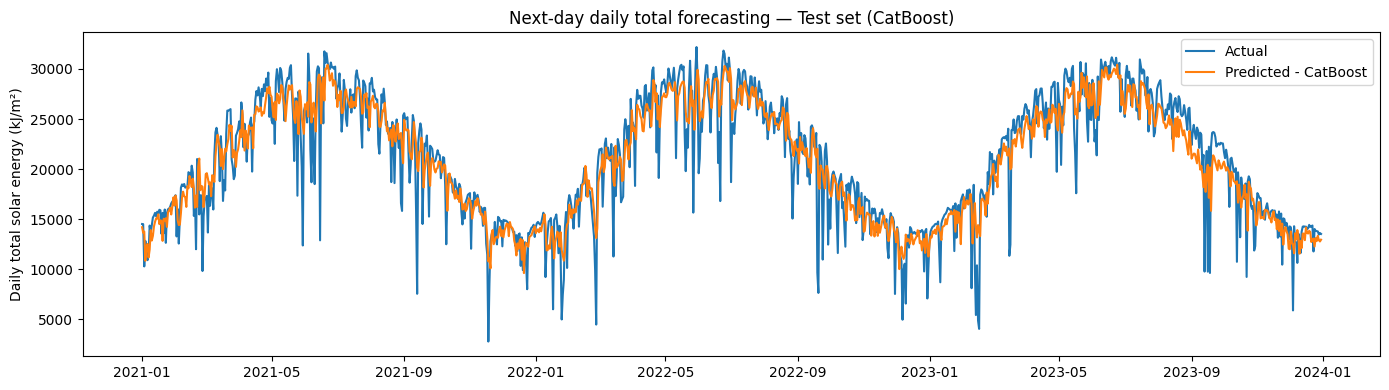

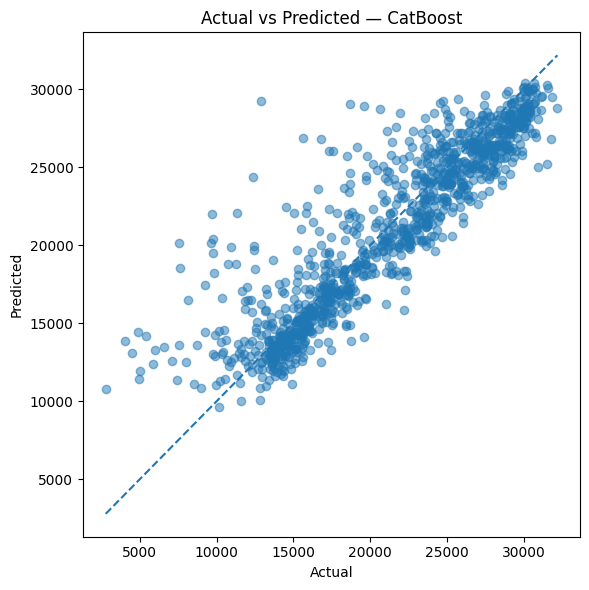

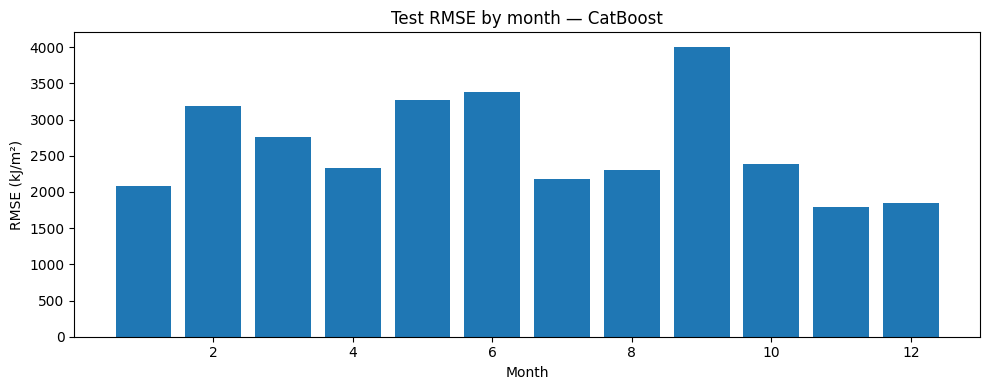

,month,MAE,RMSE,n
0,1,1513.913408,2075.656685,93
1,2,2177.055353,3191.845483,84
2,3,2165.060749,2763.107288,93
3,4,1936.396979,2328.443160,90
4,5,2448.332874,3267.559710,93
5,6,2195.736506,3383.378118,90
6,7,1663.734934,2173.759636,93
7,8,1771.820622,2307.429940,93
8,9,2898.817783,4004.456134,90
9,10,1777.527033,2379.384234,93


In [14]:
# =========================
# 13. Visualizations for best model
# =========================

plt.figure(figsize=(14, 4))
plt.plot(test_df.index, y_test, label="Actual", linewidth=1.5)
plt.plot(test_df.index, best_test_pred, label=f"Predicted - {best_model_name}", linewidth=1.5)
plt.title(f"Next-day daily total forecasting — Test set ({best_model_name})")
plt.ylabel("Daily total solar energy (kJ/m²)")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "05_best_model_actual_vs_predicted_test.png", dpi=160)
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_test_pred, alpha=0.5)
min_v = min(np.min(y_test), np.min(best_test_pred))
max_v = max(np.max(y_test), np.max(best_test_pred))
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
plt.title(f"Actual vs Predicted — {best_model_name}")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_best_model_scatter_test.png", dpi=160)
plt.show()

err_df = pd.DataFrame({"actual": y_test, "pred": best_test_pred}, index=test_df.index)
err_df["abs_error"] = np.abs(err_df["actual"] - err_df["pred"])
err_df["squared_error"] = (err_df["actual"] - err_df["pred"]) ** 2
err_df["month"] = err_df.index.month
monthly_error = err_df.groupby("month").agg(
    MAE=("abs_error", "mean"),
    RMSE=("squared_error", lambda x: float(np.sqrt(np.mean(x)))),
    n=("actual", "size"),
).reset_index()

plt.figure(figsize=(10, 4))
plt.bar(monthly_error["month"], monthly_error["RMSE"])
plt.title(f"Test RMSE by month — {best_model_name}")
plt.xlabel("Month")
plt.ylabel("RMSE (kJ/m²)")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_best_model_rmse_by_month.png", dpi=160)
plt.show()

display(monthly_error)

## 12. Feature importance

Nếu best model là tree-based thì dùng native feature importance; nếu là linear pipeline thì dùng trị tuyệt đối hệ số; nếu không, dùng permutation importance.

,feature,importance,method,model
0,daily_total_kJ_m2,9.047084,native_feature_importance,CatBoost
52,daily_total_roll_std_180d,6.949417,native_feature_importance,CatBoost
1,daily_radiation_Wh_m2,5.050044,native_feature_importance,CatBoost
34,daily_total_roll_max_7d,4.998960,native_feature_importance,CatBoost
119,current_clear_sky_index_daily,4.330920,native_feature_importance,CatBoost
9,wind_dir_cos_mean,4.111696,native_feature_importance,CatBoost
121,sim_pv_daily_kWh_per_kWp,3.840838,native_feature_importance,CatBoost
118,current_clear_sky_daily_proxy,3.717465,native_feature_importance,CatBoost
35,daily_total_roll_mean_14d,3.085140,native_feature_importance,CatBoost
115,target_noon_solar_elevation_deg,2.154956,native_feature_importance,CatBoost


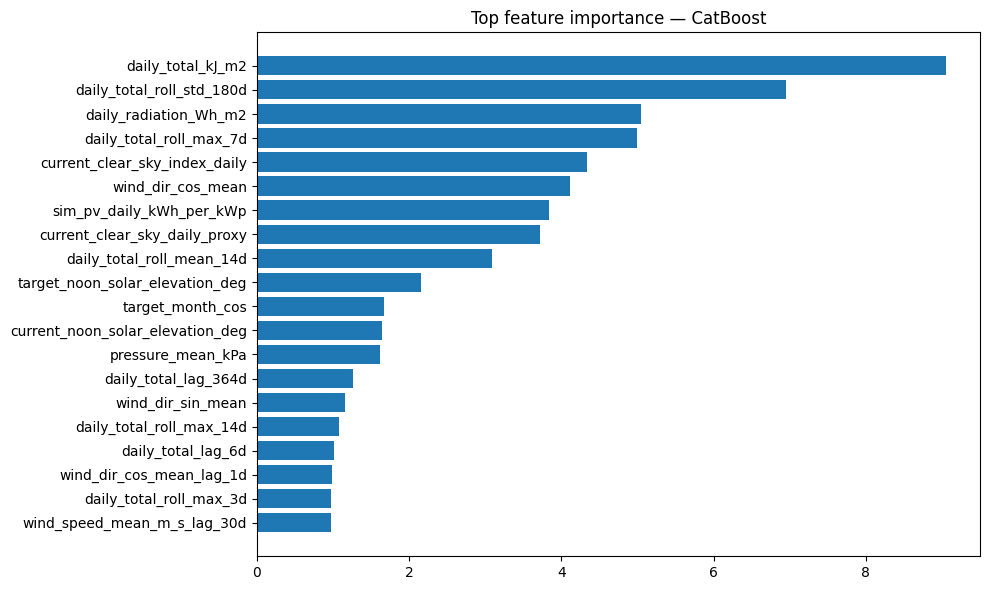

In [15]:
# =========================
# 14. Feature importance
# =========================

importance_df = pd.DataFrame()

if best_model is not None:
    try:
        if hasattr(best_model, "feature_importances_"):
            importance_df = pd.DataFrame({
                "feature": list(X_train.columns),
                "importance": best_model.feature_importances_,
                "method": "native_feature_importance",
                "model": best_model_name,
            }).sort_values("importance", ascending=False)
        elif isinstance(best_model, Pipeline) and hasattr(best_model.named_steps.get("model"), "coef_"):
            coefs = best_model.named_steps["model"].coef_
            importance_df = pd.DataFrame({
                "feature": list(X_train.columns),
                "importance": np.abs(coefs),
                "signed_coefficient": coefs,
                "method": "absolute_linear_coefficient",
                "model": best_model_name,
            }).sort_values("importance", ascending=False)
        elif RUN_PERMUTATION_IMPORTANCE:
            perm = permutation_importance(
                best_model,
                X_test,
                y_test,
                n_repeats=8,
                random_state=SEED,
                scoring="neg_root_mean_squared_error",
                n_jobs=-1,
            )
            importance_df = pd.DataFrame({
                "feature": list(X_test.columns),
                "importance": perm.importances_mean,
                "importance_std": perm.importances_std,
                "method": "permutation_importance_rmse",
                "model": best_model_name,
            }).sort_values("importance", ascending=False)
    except Exception as e:
        print("Feature importance failed:", repr(e))

if not importance_df.empty:
    display(importance_df.head(20))
    plt.figure(figsize=(10, 6))
    top = importance_df.head(20).iloc[::-1]
    plt.barh(top["feature"], top["importance"])
    plt.title(f"Top feature importance — {best_model_name}")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "05_feature_importance_top20.png", dpi=160)
    plt.show()
else:
    print("No feature importance available.")

## 13. Save outputs and compare with notebook 04

Nếu notebook 04 đã chạy và có `outputs_04/04_daily_results_all_models.csv`, notebook 05 sẽ tự đọc để so sánh 3 năm vs 20 năm.

In [16]:
# =========================
# 15. Save outputs and compare with notebook 04
# =========================

all_results_df = pd.DataFrame(results).sort_values("val_RMSE").reset_index(drop=True)
all_results_df["experiment"] = "05_daily_total_20y_2004_2023"
all_results_df["task"] = "next_day_daily_total"

# Save compact but sufficient outputs
all_results_df.to_csv(OUT_DIR / "05_daily_20y_results_all_models.csv", index=False)
if not ablation_df.empty:
    ablation_df.to_csv(OUT_DIR / "05_daily_20y_ablation.csv", index=False)
if not importance_df.empty:
    importance_df.to_csv(OUT_DIR / "05_daily_20y_feature_importance.csv", index=False)
monthly_error.to_csv(OUT_DIR / "05_daily_20y_error_by_month.csv", index=False)

summary_rows = [{
    "experiment": "05_daily_total_20y_2004_2023",
    "task": "next_day_daily_total",
    "selected_by": "validation_RMSE",
    "best_model": best_model_name,
    "val_RMSE": float(best_row["val_RMSE"]),
    "test_RMSE": float(best_row["test_RMSE"]),
    "test_R2": float(best_row["test_R2"]),
    "test_skill_vs_persistence": float(best_row["test_skill_vs_persistence"]),
    "test_skill_vs_seasonal7": float(best_row["test_skill_vs_seasonal7"]),
    "test_skill_vs_seasonal365": float(best_row["test_skill_vs_seasonal365"]),
    "n_train_days": len(train_df),
    "n_val_days": len(val_df),
    "n_test_days": len(test_df),
    "n_features": len(feature_cols),
}]

path_04 = Path("outputs_04/04_daily_results_all_models.csv")
if path_04.exists():
    try:
        res04 = pd.read_csv(path_04)
        if "val_RMSE" in res04.columns:
            best04 = res04.sort_values("val_RMSE").iloc[0]
            summary_rows.append({
                "experiment": "04_daily_total_3y_2016_2018",
                "task": "next_day_daily_total",
                "selected_by": "validation_RMSE",
                "best_model": best04.get("model", np.nan),
                "val_RMSE": best04.get("val_RMSE", np.nan),
                "test_RMSE": best04.get("test_RMSE", np.nan),
                "test_R2": best04.get("test_R2", np.nan),
                "test_skill_vs_persistence": best04.get("test_skill_vs_persistence", np.nan),
                "test_skill_vs_seasonal7": best04.get("test_skill_vs_seasonal7", np.nan),
                "test_skill_vs_seasonal365": best04.get("test_skill_vs_seasonal365", np.nan),
                "n_train_days": np.nan,
                "n_val_days": np.nan,
                "n_test_days": np.nan,
                "n_features": np.nan,
            })
    except Exception as e:
        print("Could not read notebook 04 results:", repr(e))
else:
    print("Notebook 04 results not found. Comparison will include only notebook 05.")

comparison_df = pd.DataFrame(summary_rows)
comparison_df.to_csv(OUT_DIR / "05_final_daily_comparison.csv", index=False)

display(comparison_df)
print("Saved outputs to:", OUT_DIR.resolve())
print("Saved figures to:", FIG_DIR.resolve())
print("Saved models to :", MODEL_DIR.resolve())

,experiment,task,selected_by,best_model,val_RMSE,test_RMSE,test_R2,test_skill_vs_persistence,test_skill_vs_seasonal7,test_skill_vs_seasonal365,n_train_days,n_val_days,n_test_days,n_features
0,05_daily_total_20y_2004_2023,next_day_daily_total,validation_RMSE,CatBoost,2324.939979,2701.754582,0.805475,0.171569,0.340947,0.368042,5114.0,731.0,1094.0,126.0
1,04_daily_total_3y_2016_2018,next_day_daily_total,validation_RMSE,Ridge,2816.775639,2978.157484,0.700323,0.071475,0.312590,NaN,NaN,NaN,NaN,NaN


Saved outputs to: C:\Users\nguye\Downloads\Big_Data\outputs_05
Saved figures to: C:\Users\nguye\Downloads\Big_Data\figures_05
Saved models to : C:\Users\nguye\Downloads\Big_Data\models_05
